## Examples: The train-test split

#### In this notebook, we will examine the need for unseen data when assessing the performance of a model and how we can simulate it by splitting our existing dataset in various ways.

### Learning Objectives

#### By the end of this lesson, we will:
##### - Know why and how to split a dataset into training and testing subsets.
##### - Konw what is meant by a validation set and why it is important.
##### - Carry out the train-test-split using ***sklearn*** in Python.
##### - Be able to review the performance of a model using the training and testing sets

### The train-test split in Python

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/regression_sprint/regression_sprint_data_1.csv', index_col=0)

### Using the train_test_split function from sklearn

In [3]:
# import the split function from sklearn
from sklearn.model_selection import train_test_split

In [6]:
# split the dataset into the response, y, and features, x
y = df['ZAR/USD']
X = df.drop('ZAR/USD', axis=1)

In [7]:
# Call the 'train_test_split' function
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

### Plotting the training and testing sets

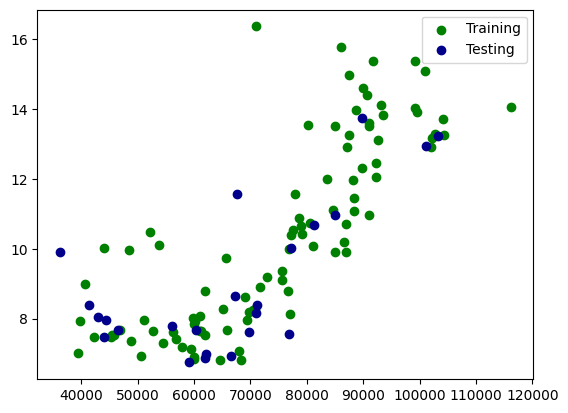

In [9]:
# Plot the splitting results
plt.scatter(X_train, y_train, color='green', label='Training') # plot the training data in green
plt.scatter(X_test, y_test, color='darkblue', label='Testing') # plot the testing data in blue
plt.legend()
plt.show()

### Training a linear model

In [10]:
# importing the linear regression module
from sklearn.linear_model import LinearRegression

In [11]:
# declare the model object
lm = LinearRegression()

In [12]:
# Fit the model to the training data
lm.fit(X_train, y_train)

LinearRegression()

In [13]:
# Extract the intercept, or y-cut, of our Linear model
a = float(lm.intercept_)

In [14]:
# Extract the coeeficient, or gradient, of our linear model
b = lm.coef_

In [16]:
print("Slop:\t\t", b)
print("Intercept:\t", float(a))

Slop:		 [0.0001199]
Intercept:	 1.4542630444144784


### Assessing the model on the training data

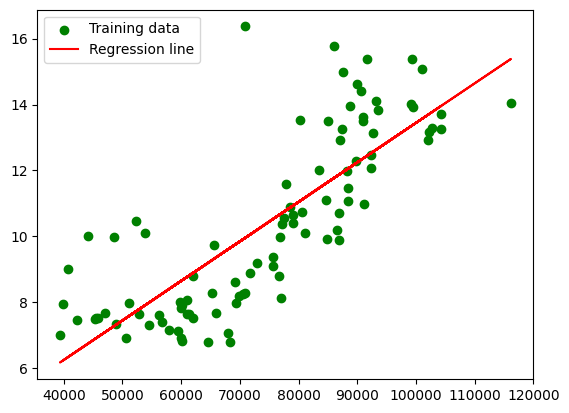

In [17]:
# Generate the values that fall along our regression line
gen_y = lm.predict(X_train)

# Plot the results
plt.scatter(X_train, y_train, color='green', label='Training data') # Plot the training data in green
plt.plot(X_train, gen_y, color='red', label='Regression line') # Plot the line connecting the generated y-values
plt.legend()
plt.show()

In [18]:
from sklearn import metrics

In [19]:
print("Training:")
# Calculate the mean-squared-error
print('MSE:', metrics.mean_squared_error(y_train, gen_y))
# Calculate the R² metric
print('R²:', metrics.r2_score(y_train, gen_y))

Training:
MSE: 2.612547537558907
R²: 0.6402293095045937


### Assessing the model on the testing (unseen) data

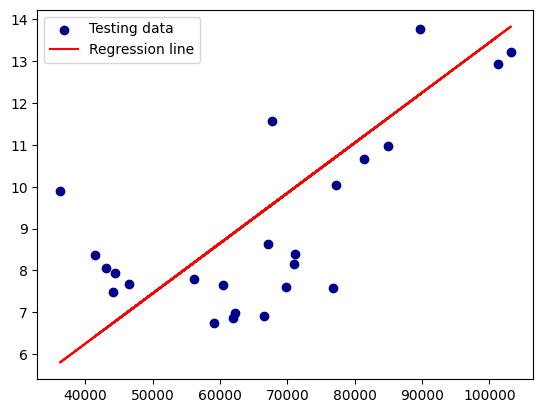

In [20]:
# Generate values of y from x, using the linear model
gen_y_test = lm.predict(X_test)

# Plot the results
plt.scatter(X_test, y_test, color='darkblue', label='Testing data') # Plot the testing data in blue
plt.plot(X_test, gen_y_test, color='red', label='Regression line') # Plot the line connecting the generated y-values in red
plt.legend()
plt.show()

In [21]:
print("Testing:")
print('MSE:', metrics.mean_squared_error(y_test, gen_y_test))
print('R²:', metrics.r2_score(y_test, gen_y_test))

Testing:
MSE: 3.038981977599917
R²: 0.3003104341257886
